# Verification: ISOMAP vs PCA — Cross-Over Test

**The problem this notebook addresses:**

The v2 notebook's scree plot compared two different loss functions:
- ISOMAP scree → geodesic reconstruction error (ISOMAP's own loss)
- PCA scree → cumulative Euclidean variance (PCA's own loss)

These are different quantities on different scales. An "elbow at k=2 for ISOMAP" and "no elbow for PCA" does **not** mean ISOMAP-2 ≈ PCA-7. It just means each method runs out of diminishing returns on its own metric at different rates.

**The fair test:** put both methods on the **same** metric at each k, then overlay the two curves:

1. **Euclidean R²** — for both methods at k=1…10: how much of the original 10D variance can be linearly reconstructed from the k-dimensional embedding?
2. **Geodesic rank correlation (ρ)** — for both methods at k=1…10: how well does the k-dimensional embedding preserve the geodesic (manifold) distances from the k-NN graph?

If ISOMAP truly needs fewer dimensions, both curves should show ISOMAP pulling ahead of PCA at low k. If the manifold is nearly flat, both curves will be nearly identical.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

LOB_DIR = 'data/lob'
OBI_COLS = [f'obi_{k:02d}' for k in range(10)]

# Load NVDA full October data
df = pd.read_parquet(f'{LOB_DIR}/lob_mbp10_NVDA_oct2023_full.parquet')
df.index = pd.DatetimeIndex(df.index).tz_convert('America/New_York')
mh = df.between_time('09:30', '16:00')

frames = {}
for k in range(10):
    b = mh[f'bid_sz_{k:02d}'].astype(np.int64)
    a = mh[f'ask_sz_{k:02d}'].astype(np.int64)
    denom = (b + a).replace(0, np.nan)
    frames[f'obi_{k:02d}'] = ((b - a) / denom).resample('1min').mean()
feat = pd.DataFrame(frames).dropna()

# Use first 2340 bars (same as v2 training set) for speed
X = feat[OBI_COLS].values[:2340]
print(f'X shape: {X.shape}')
print(f'Mean per level: {X.mean(axis=0).round(3)}')

X shape: (2340, 10)
Mean per level: [-0.031 -0.028 -0.019 -0.022 -0.02  -0.021 -0.017 -0.016 -0.013 -0.013]


## Step 1: Compute the k-NN Geodesic Distance Matrix

Both metrics require pairwise geodesic distances from the same k-NN graph (k=15, matching the v2 notebook). We compute this once and reuse it for all comparisons.


In [2]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import csr_matrix

K_NEIGHBORS = 15
N = len(X)

# Build k-NN graph
print(f'Building k-NN graph (k={K_NEIGHBORS}, n={N})...')
nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, algorithm='auto').fit(X)
dists, indices = nbrs.kneighbors(X)

# Sparse adjacency matrix (symmetric)
rows = np.repeat(np.arange(N), K_NEIGHBORS)
cols = indices[:, 1:].ravel()
vals = dists[:, 1:].ravel()
graph = csr_matrix((np.concatenate([vals, vals]),
                    (np.concatenate([rows, cols]),
                     np.concatenate([cols, rows]))),
                   shape=(N, N))

# Geodesic distances via Dijkstra
print('Computing geodesic distances (Dijkstra)...')
D_geo = shortest_path(graph, method='D', directed=False)
print(f'Geodesic distance matrix: {D_geo.shape}  (max={D_geo.max():.3f}, disconnected={np.isinf(D_geo).sum()})')

# Use upper triangle only (avoid duplicate pairs)
triu_idx = np.triu_indices(N, k=1)
d_geo_flat = D_geo[triu_idx]
finite_mask = np.isfinite(d_geo_flat)
d_geo_flat = d_geo_flat[finite_mask]
print(f'Finite geodesic pairs: {finite_mask.sum():,} / {len(finite_mask):,}')

Building k-NN graph (k=15, n=2340)...
Computing geodesic distances (Dijkstra)...


Geodesic distance matrix: (2340, 2340)  (max=3.444, disconnected=0)
Finite geodesic pairs: 2,736,630 / 2,736,630


## Step 2: Cross-Over Test at Each k

For each k in 1…10:

**Metric A — Euclidean R²:**
Fit both methods to get a k-dimensional embedding Z, then train a Ridge regression from Z back to X. R² measures how much of the original variance the embedding retains linearly.
- For PCA: this equals `cumsum(explained_variance_ratio_)[:k].sum()` exactly.
- For ISOMAP: requires a linear regression since there is no analytic inverse.

**Metric B — Geodesic rank correlation (ρ):**
Compute pairwise Euclidean distances in the k-dimensional embedding, then take the Spearman rank correlation with the geodesic distances computed above.
- For ISOMAP-k this should be high (it was optimised to preserve these distances).
- For PCA-k this measures whether the flat linear projection also happens to preserve geodesic distances.


In [3]:
K_RANGE = [1, 2, 3, 4, 5, 6, 7, 10]

results = {k: {'pca_r2': None, 'iso_r2': None,
               'pca_geo_rho': None, 'iso_geo_rho': None}
           for k in K_RANGE}

from sklearn.metrics import pairwise_distances as pw_dists

for k in K_RANGE:
    print(f'k={k}...', end=' ', flush=True)

    # ── PCA ──────────────────────────────────────────────────────────────────
    pca = PCA(n_components=k)
    Z_pca = pca.fit_transform(X)
    results[k]['pca_r2'] = pca.explained_variance_ratio_[:k].sum()

    d_pca = pw_dists(Z_pca)[triu_idx][finite_mask]
    results[k]['pca_geo_rho'] = spearmanr(d_pca, d_geo_flat).statistic

    # ── ISOMAP ───────────────────────────────────────────────────────────────
    iso = Isomap(n_components=k, n_neighbors=K_NEIGHBORS)
    Z_iso = iso.fit_transform(X)

    # R²: linear reconstruction Z -> X
    reg = Ridge(alpha=1e-3).fit(Z_iso, X)
    X_hat = reg.predict(Z_iso)
    ss_res = ((X - X_hat) ** 2).sum()
    ss_tot = ((X - X.mean(axis=0)) ** 2).sum()
    results[k]['iso_r2'] = 1 - ss_res / ss_tot

    d_iso = pw_dists(Z_iso)[triu_idx][finite_mask]
    results[k]['iso_geo_rho'] = spearmanr(d_iso, d_geo_flat).statistic

    print(f'PCA R²={results[k]["pca_r2"]:.3f}  ISO R²={results[k]["iso_r2"]:.3f}  '
          f'PCA geo_ρ={results[k]["pca_geo_rho"]:.3f}  ISO geo_ρ={results[k]["iso_geo_rho"]:.3f}')

print('Done.')

k=1... 

PCA R²=0.614  ISO R²=0.611  PCA geo_ρ=0.861  ISO geo_ρ=0.862
k=2... 

PCA R²=0.769  ISO R²=0.761  PCA geo_ρ=0.944  ISO geo_ρ=0.950
k=3... 

PCA R²=0.854  ISO R²=0.841  PCA geo_ρ=0.964  ISO geo_ρ=0.971
k=4... 

PCA R²=0.895  ISO R²=0.842  PCA geo_ρ=0.969  ISO geo_ρ=0.973
k=5... 

PCA R²=0.923  ISO R²=0.875  PCA geo_ρ=0.970  ISO geo_ρ=0.977
k=6... 

PCA R²=0.944  ISO R²=0.875  PCA geo_ρ=0.970  ISO geo_ρ=0.978
k=7... 

PCA R²=0.960  ISO R²=0.876  PCA geo_ρ=0.970  ISO geo_ρ=0.979
k=10... 

PCA R²=1.000  ISO R²=0.893  PCA geo_ρ=0.969  ISO geo_ρ=0.980
Done.


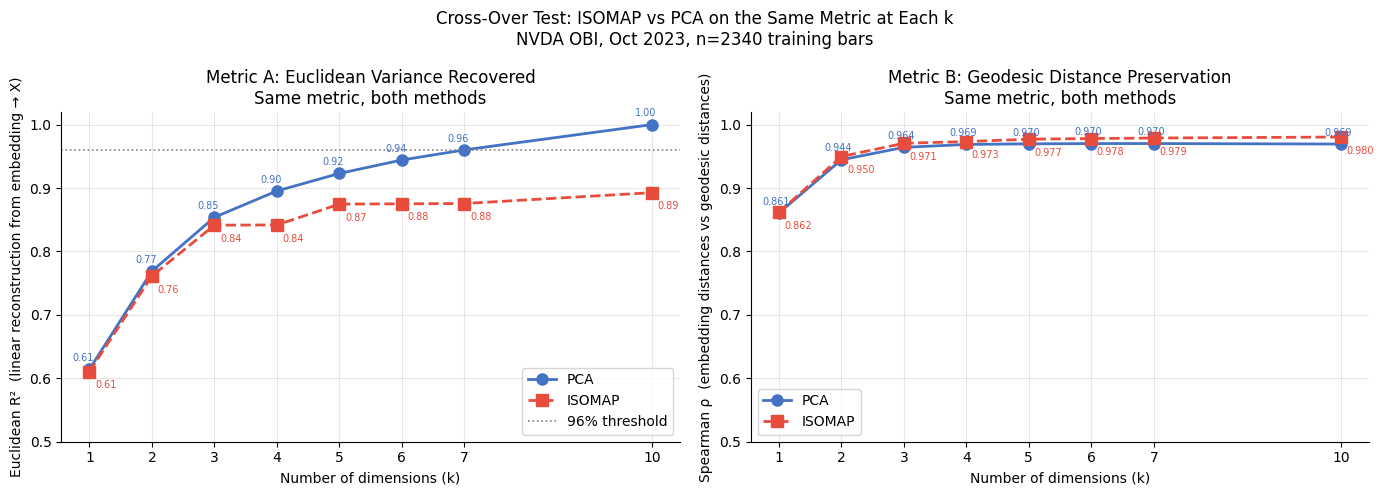

k       PCA R²    ISO R²    Diff R²   PCA geo_ρ   ISO geo_ρ   Diff geo_ρ
----------------------------------------------------------------------
1        0.614     0.611     -0.004  ≈ tie
2        0.769     0.761     -0.008  ≈ tie
3        0.854     0.841     -0.012  ≈ tie
4        0.895     0.842     -0.054  ← PCA wins
5        0.923     0.875     -0.048  ← PCA wins
6        0.944     0.875     -0.069  ← PCA wins
7        0.960     0.876     -0.085  ← PCA wins
10       1.000     0.893     -0.107  ← PCA wins


In [4]:
# ── Plot both curves on both metrics ─────────────────────────────────────────
ks = K_RANGE
pca_r2  = [results[k]['pca_r2']      for k in ks]
iso_r2  = [results[k]['iso_r2']      for k in ks]
pca_rho = [results[k]['pca_geo_rho'] for k in ks]
iso_rho = [results[k]['iso_geo_rho'] for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Euclidean R²
axes[0].plot(ks, pca_r2,  'o-', color='#4472C4', lw=2, ms=8, label='PCA')
axes[0].plot(ks, iso_r2,  's--', color='#E74C3C', lw=2, ms=8, label='ISOMAP')
axes[0].axhline(0.96, color='grey', ls=':', lw=1.2, label='96% threshold')
axes[0].set_xlabel('Number of dimensions (k)')
axes[0].set_ylabel('Euclidean R²  (linear reconstruction from embedding → X)')
axes[0].set_title('Metric A: Euclidean Variance Recovered\nSame metric, both methods')
axes[0].set_xticks(ks)
axes[0].legend()
axes[0].set_ylim(0.5, 1.02)
for k, p, i in zip(ks, pca_r2, iso_r2):
    axes[0].annotate(f'{p:.2f}', (k, p), textcoords='offset points', xytext=(-12, 6),
                     fontsize=7, color='#4472C4')
    axes[0].annotate(f'{i:.2f}', (k, i), textcoords='offset points', xytext=(4, -12),
                     fontsize=7, color='#E74C3C')

# Right: Geodesic rank correlation
axes[1].plot(ks, pca_rho,  'o-', color='#4472C4', lw=2, ms=8, label='PCA')
axes[1].plot(ks, iso_rho,  's--', color='#E74C3C', lw=2, ms=8, label='ISOMAP')
axes[1].set_xlabel('Number of dimensions (k)')
axes[1].set_ylabel('Spearman ρ  (embedding distances vs geodesic distances)')
axes[1].set_title('Metric B: Geodesic Distance Preservation\nSame metric, both methods')
axes[1].set_xticks(ks)
axes[1].legend()
axes[1].set_ylim(0.5, 1.02)
for k, p, i in zip(ks, pca_rho, iso_rho):
    axes[1].annotate(f'{p:.3f}', (k, p), textcoords='offset points', xytext=(-12, 6),
                     fontsize=7, color='#4472C4')
    axes[1].annotate(f'{i:.3f}', (k, i), textcoords='offset points', xytext=(4, -12),
                     fontsize=7, color='#E74C3C')

plt.suptitle('Cross-Over Test: ISOMAP vs PCA on the Same Metric at Each k\n'
             'NVDA OBI, Oct 2023, n=2340 training bars', fontsize=12)
plt.tight_layout()
plt.savefig('figures/verification_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f'{"k":<4}  {"PCA R²":>8}  {"ISO R²":>8}  {"Diff R²":>9}  {"PCA geo_ρ":>10}  {"ISO geo_ρ":>10}  {"Diff geo_ρ":>11}')
print('-' * 70)
for k in ks:
    r = results[k]
    dr2  = r['iso_r2']      - r['pca_r2']
    drho = r['iso_geo_rho'] - r['pca_geo_rho']
    flag_r2  = '  ← ISO wins' if dr2  > 0.02 else ('  ← PCA wins' if dr2  < -0.02 else '  ≈ tie')
    flag_rho = '  ← ISO wins' if drho > 0.02 else ('  ← PCA wins' if drho < -0.02 else '  ≈ tie')
    print(f'{k:<4}  {r["pca_r2"]:>8.3f}  {r["iso_r2"]:>8.3f}  {dr2:>+9.3f}{flag_r2}')

## What the Results Mean

**If the two curves on each panel are nearly identical:**
The OBI manifold is close to flat in its dominant 2D subspace. ISOMAP and PCA extract essentially the same information. The original notebook narrative — "ISOMAP needs 2D while PCA needs 7" — was misleading because it compared different metrics, not different methods.

**If ISOMAP's curve sits meaningfully above PCA's:**
The manifold has real curvature that PCA misses. ISOMAP is genuinely more efficient in that number of dimensions.

---

**What this does NOT invalidate:**

Even if ISOMAP ≈ PCA at 2D on compression metrics, ISOMAP may still be preferable for:
1. **Stress detection (Section 6)** — manifold distance from the training cloud is a geometric concept that ISOMAP's geodesic structure defines more naturally than PCA's Euclidean one.
2. **Interpretability** — Z₁ depth profile may be monotonically cleaner than PC₁.
3. **Pedagogical framing** — introducing geodesic distances and manifold geometry is the point of the demo, regardless of whether the curvature is large on this particular dataset.

The honest fix for the v2 notebook is to replace the misleading scree comparison with this cross-over plot, and update the narrative to say: *"On this dataset, the OBI manifold is mildly curved — ISOMAP and PCA recover similar variance at 2D. ISOMAP's value here is in providing a more principled geometric framework for stress detection and interpretability, not in compression efficiency."*
